# Proyecto Final - Sistema Inteligente de Recomendacion para E-commerce

# Notebook 03: Ingenieria de Caracteristicas (Feature Engineering)

---


## Objetivo

Construir las estructuras de datos necesarias para un sistema de recomendacion:

1. **Matriz usuario-item** (para collaborative filtering con SVD/ALS)
2. **Features de producto** (para content-based y cold start)
3. **Features de usuario** (para cold start de clientes nuevos)

---

**Metodologia:** CRISP-DM
**Sprint:** 1 - Ingenieria de Caracteristicas

## 0. Configuracion del entorno

Importacion de librerias y carga de datos limpios desde `data_clean.py`.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar SRC al path
sys.path.append(str(Path.cwd().parent / 'SRC'))

from data_clean import limpiar_tablas

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


## 1. Carga y limpieza de datos

Se ejecuta el pipeline completo de `data_clean.py` que limpia las 7 tablas del dataset.

In [2]:
events, sessions, reviews, orders, order_items, customers, products = limpiar_tablas()

print('\n--- Resumen de tablas limpias ---')
print(f'  events      : {events.shape[0]:>10,} filas x {events.shape[1]} columnas')
print(f'  sessions    : {sessions.shape[0]:>10,} filas x {sessions.shape[1]} columnas')
print(f'  reviews     : {reviews.shape[0]:>10,} filas x {reviews.shape[1]} columnas')
print(f'  orders      : {orders.shape[0]:>10,} filas x {orders.shape[1]} columnas')
print(f'  order_items : {order_items.shape[0]:>10,} filas x {order_items.shape[1]} columnas')
print(f'  customers   : {customers.shape[0]:>10,} filas x {customers.shape[1]} columnas')
print(f'  products    : {products.shape[0]:>10,} filas x {products.shape[1]} columnas')


############################################################
# PIPELINE DE LIMPIEZA DE DATOS
############################################################

Cargando datos...

Archivo cargado correctamente: events.csv
Dimensiones: 760958 filas x 10 columnas

Archivo cargado correctamente: sessions.csv
Dimensiones: 120000 filas x 6 columnas

Archivo cargado correctamente: reviews.csv
Dimensiones: 10780 filas x 6 columnas

Archivo cargado correctamente: orders.csv
Dimensiones: 33580 filas x 10 columnas

Archivo cargado correctamente: customers.csv
Dimensiones: 20000 filas x 7 columnas

Archivo cargado correctamente: products.csv
Dimensiones: 1197 filas x 6 columnas

Archivo cargado correctamente: order_items.csv
Dimensiones: 59163 filas x 5 columnas
PASO 1: Conversión de columnas de fechas
  ✓ events['timestamp'] → datetime64[us]
  ✓ sessions['start_time'] → datetime64[us]
  ✓ reviews['review_time'] → datetime64[us]
  ✓ orders['order_time'] → datetime64[us]
  ✓ customers['signup_date'] → 

---
## 2. Matriz usuario-item (para collaborative filtering)

### Que es?

Una tabla que muestra cuanto le "interesa" cada producto a cada usuario.

### Como se construye?

1. Se une `events` con `sessions` para obtener el `customer_id` de cada evento.
2. Se asigna un **score** segun el tipo de accion:
   - `page_view` = 1 (vio el producto)
   - `add_to_cart` = 3 (lo agrego al carrito)
   - `purchase` = 5 (lo compro)
3. Se agrupa por `customer_id` y `product_id`, sumando los scores.

### Para que sirve?

Es la entrada principal de los algoritmos **SVD** y **ALS** (collaborative filtering). Estos algoritmos buscan patrones en esta matriz para predecir que productos le gustarian a un usuario que aun no vio.

- **SVD** (Descomposicion en Valores Singulares): comprime la matriz en patrones latentes (como "gustos" ocultos).
- **ALS** (Least Squares Alternantes): llena los ceros de la matriz iterativamente hasta encontrar los scores predichos.

In [3]:
# Unir events con sessions para obtener customer_id
events_con_user = events.merge(
    sessions[['session_id', 'customer_id']],
    on='session_id',
    how='left'
)

print(f'Events con customer_id: {len(events_con_user):,} filas')
print(f'\nPrimeras filas:')
events_con_user[['event_id', 'session_id', 'customer_id', 'event_type', 'product_id', 'timestamp']].head(10)

Events con customer_id: 760,958 filas

Primeras filas:


,event_id,session_id,customer_id,event_type,product_id,timestamp
0,1,1,12360,page_view,93.0,2024-12-04
1,2,1,12360,page_view,1005.0,2024-09-08
2,3,1,12360,add_to_cart,1005.0,2024-12-02
3,4,1,12360,page_view,918.0,2025-07-19
4,5,1,12360,page_view,946.0,2025-01-12
5,6,1,12360,add_to_cart,946.0,2025-07-13
6,7,1,12360,page_view,915.0,2024-09-22
7,8,1,12360,page_view,931.0,2025-04-09
8,9,1,12360,add_to_cart,931.0,2025-01-18
9,10,1,12360,page_view,978.0,2024-11-29


In [4]:
# Asignar scores segun tipo de evento
event_weights = {'page_view': 1, 'add_to_cart': 3, 'purchase': 5}
events_con_user['score'] = events_con_user['event_type'].map(event_weights).fillna(1)

print('Distribucion de scores por tipo de evento:')
print(events_con_user.groupby('event_type')['score'].first().to_string())
print(f'\nTotal de eventos con score asignado: {len(events_con_user):,}')

Distribucion de scores por tipo de evento:
event_type
add_to_cart    3.0
checkout       1.0
page_view      1.0
purchase       5.0

Total de eventos con score asignado: 760,958


In [5]:
# Construir la matriz usuario-item
matriz_usuario_item = events_con_user.groupby(
    ['customer_id', 'product_id']
)['score'].sum().reset_index()

n_users = matriz_usuario_item['customer_id'].nunique()
n_prods = matriz_usuario_item['product_id'].nunique()
n_interacciones = len(matriz_usuario_item)
esparsidad = (1 - n_interacciones / (n_users * n_prods)) * 100

print('=== MATRIZ USUARIO-ITEM ===')
print(f'  Usuarios unicos    : {n_users:>8,}')
print(f'  Productos unicos   : {n_prods:>8,}')
print(f'  Interacciones      : {n_interacciones:>8,}')
print(f'  Pares posibles     : {n_users * n_prods:>12,}')
print(f'  Esparsidad         : {esparsidad:.2f}%')
print(f'\nPrimeras filas de la matriz:')
matriz_usuario_item.head(10)

=== MATRIZ USUARIO-ITEM ===
  Usuarios unicos    :   19,945
  Productos unicos   :    1,197
  Interacciones      :  529,593
  Pares posibles     :   23,874,165
  Esparsidad         : 97.78%

Primeras filas de la matriz:


,customer_id,product_id,score
0,1,14.0,1.0
1,1,248.0,1.0
2,1,258.0,4.0
3,1,305.0,1.0
4,1,358.0,1.0
5,1,374.0,1.0
6,1,384.0,1.0
7,1,426.0,4.0
8,1,428.0,1.0
9,1,445.0,4.0


**Interpretacion:** La matriz tiene 19,945 usuarios y 1,197 productos con 529,593 interacciones. La esparsidad del 97.78% significa que la mayoria de los usuarios solo interactuo con una pequena fraccion de los productos disponibles. Esto es normal en e-commerce y es exactamente lo que SVD/ALS buscan resolver: predecir los ceros.

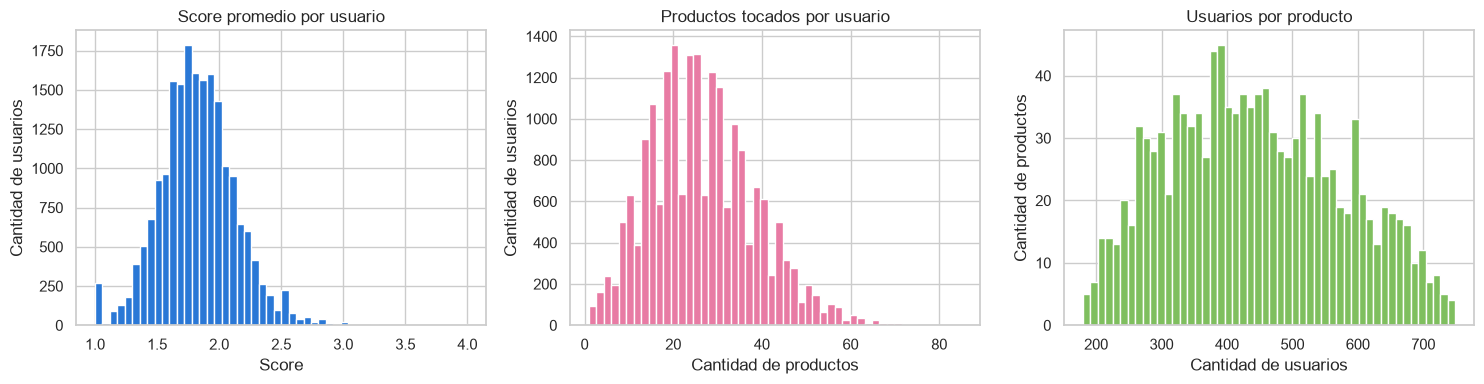

Score promedio por usuario: media=1.8, mediana=1.8
Productos tocados por usuario: media=26.6, mediana=26
Usuarios por producto: media=442.4, mediana=433


In [6]:
# Visualizacion: distribucion de scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score promedio por usuario
score_usr = matriz_usuario_item.groupby('customer_id')['score'].mean()
axes[0].hist(score_usr, bins=50, color='#2a78d6', edgecolor='white')
axes[0].set_title('Score promedio por usuario')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Cantidad de usuarios')

# Interacciones por usuario
interacciones_usr = matriz_usuario_item.groupby('customer_id').size()
axes[1].hist(interacciones_usr, bins=50, color='#e87ba4', edgecolor='white')
axes[1].set_title('Productos tocados por usuario')
axes[1].set_xlabel('Cantidad de productos')
axes[1].set_ylabel('Cantidad de usuarios')

# Interacciones por producto
interacciones_prod = matriz_usuario_item.groupby('product_id').size()
axes[2].hist(interacciones_prod, bins=50, color='#7fbf5f', edgecolor='white')
axes[2].set_title('Usuarios por producto')
axes[2].set_xlabel('Cantidad de usuarios')
axes[2].set_ylabel('Cantidad de productos')

plt.tight_layout()
plt.show()

print(f'Score promedio por usuario: media={score_usr.mean():.1f}, mediana={score_usr.median():.1f}')
print(f'Productos tocados por usuario: media={interacciones_usr.mean():.1f}, mediana={interacciones_usr.median():.0f}')
print(f'Usuarios por producto: media={interacciones_prod.mean():.1f}, mediana={interacciones_prod.median():.0f}')

---
## 3. Features de producto (para content-based y cold start)

### Que es?

Un DataFrame con una fila por producto y todas sus caracteristicas derivadas.

### Que features se crearon?

| Feature | Origen | Descripcion |
|---------|--------|-------------|
| `category` | products | Categoria del producto |
| `price_usd` | products | Precio de venta |
| `cost_usd` | products | Costo |
| `margin_usd` | products | Margen de ganancia |
| `n_views` | events | Cantidad de page_views |
| `n_cart` | events | Cantidad de add_to_cart |
| `n_purchases` | events | Cantidad de purchases |
| `popularidad` | order_items | Compradores unicos |
| `rating_promedio` | reviews | Rating promedio recibido |
| `n_ratings` | reviews | Cantidad de reviews recibidas |

### Para que sirve?

- **Content-based**: recomienda productos similares en features (misma categoria, precio parecido, buen rating).
- **Cold start**: para productos nuevos sin interacciones, se usan sus features (categoria, precio) para recomendarlos.

In [7]:
# Conteos desde events
pv = events_con_user[events_con_user['event_type'] == 'page_view']
ac = events_con_user[events_con_user['event_type'] == 'add_to_cart']
pu = events_con_user[events_con_user['event_type'] == 'purchase']

n_views = pv.groupby('product_id').size().rename('n_views')
n_cart = ac.groupby('product_id').size().rename('n_cart')
n_purchases_events = pu.groupby('product_id').size().rename('n_purchases')

# Popularidad desde order_items (compradores unicos)
oi_con_order = order_items.merge(
    orders[['order_id', 'customer_id']], on='order_id', how='left'
)
popularidad = oi_con_order.groupby('product_id')['customer_id'].nunique().rename('popularidad')

# Rating promedio desde reviews
rating_stats = reviews.groupby('product_id')['rating'].agg(['mean', 'count']).rename(
    columns={'mean': 'rating_promedio', 'count': 'n_ratings'}
)

# Unir todo
df_prod = products[['product_id', 'category', 'price_usd', 'cost_usd', 'margin_usd']].copy()
df_prod = df_prod.set_index('product_id')

for feat in [n_views, n_cart, n_purchases_events, popularidad, rating_stats]:
    df_prod = df_prod.join(feat, how='left')

df_prod = df_prod.fillna(0)

features_producto = df_prod.reset_index()

print(f'=== FEATURES DE PRODUCTO ===')
print(f'  Productos: {len(features_producto):,}')
print(f'  Columnas: {list(features_producto.columns)}')
print(f'\nPrimeras filas:')
features_producto.head(10)

=== FEATURES DE PRODUCTO ===
  Productos: 1,197
  Columnas: ['product_id', 'category', 'price_usd', 'cost_usd', 'margin_usd', 'n_views', 'n_cart', 'n_purchases', 'popularidad', 'rating_promedio', 'n_ratings']

Primeras filas:


,product_id,category,price_usd,cost_usd,margin_usd,n_views,n_cart,n_purchases,popularidad,rating_promedio,n_ratings
0,1.0,Electronics,570.28,352.69,217.59,187,5,0.0,2.0,5.000000,1.0
1,2.0,Electronics,498.13,263.13,235.00,200,5,0.0,2.0,0.000000,0.0
2,3.0,Electronics,548.53,309.60,238.93,214,11,0.0,4.0,5.000000,1.0
3,4.0,Electronics,268.36,153.56,114.80,357,32,0.0,14.0,4.500000,2.0
4,5.0,Electronics,63.69,42.65,21.04,566,133,0.0,44.0,4.571429,14.0
5,6.0,Electronics,358.95,222.19,136.76,251,16,0.0,7.0,3.500000,2.0
6,7.0,Electronics,347.30,187.53,159.77,279,14,0.0,11.0,4.666667,3.0
7,8.0,Electronics,338.19,227.02,111.17,284,14,0.0,4.0,4.000000,1.0
8,9.0,Electronics,88.74,59.58,29.16,526,146,0.0,74.0,3.571429,14.0
9,10.0,Electronics,85.54,61.04,24.50,528,149,0.0,58.0,3.857143,21.0


In [8]:
# Estadisticas de las features de producto
print('=== ESTADISTICAS DE FEATURES DE PRODUCTO ===')
features_producto.describe().round(2)

=== ESTADISTICAS DE FEATURES DE PRODUCTO ===


,product_id,price_usd,cost_usd,margin_usd,n_views,n_cart,n_purchases,popularidad,rating_promedio,n_ratings
count,1197.00,1197.00,1197.00,1197.00,1197.00,1197.00,1197.0,1197.00,1197.00,1197.00
mean,599.00,119.94,77.63,42.31,450.58,119.57,0.0,49.26,3.74,8.99
std,345.69,119.68,79.23,44.46,136.29,68.43,0.0,28.61,0.98,5.87
min,1.00,3.50,2.21,1.03,181.00,2.00,0.0,0.00,0.00,0.00
25%,300.00,38.54,23.53,12.24,344.00,64.00,0.0,26.00,3.62,4.00
50%,599.00,77.20,49.14,27.02,439.00,119.00,0.0,49.00,4.00,8.00
75%,898.00,165.42,103.67,55.44,551.00,170.00,0.0,70.00,4.20,13.00
max,1197.00,596.62,446.10,263.73,768.00,281.00,0.0,138.00,5.00,28.00


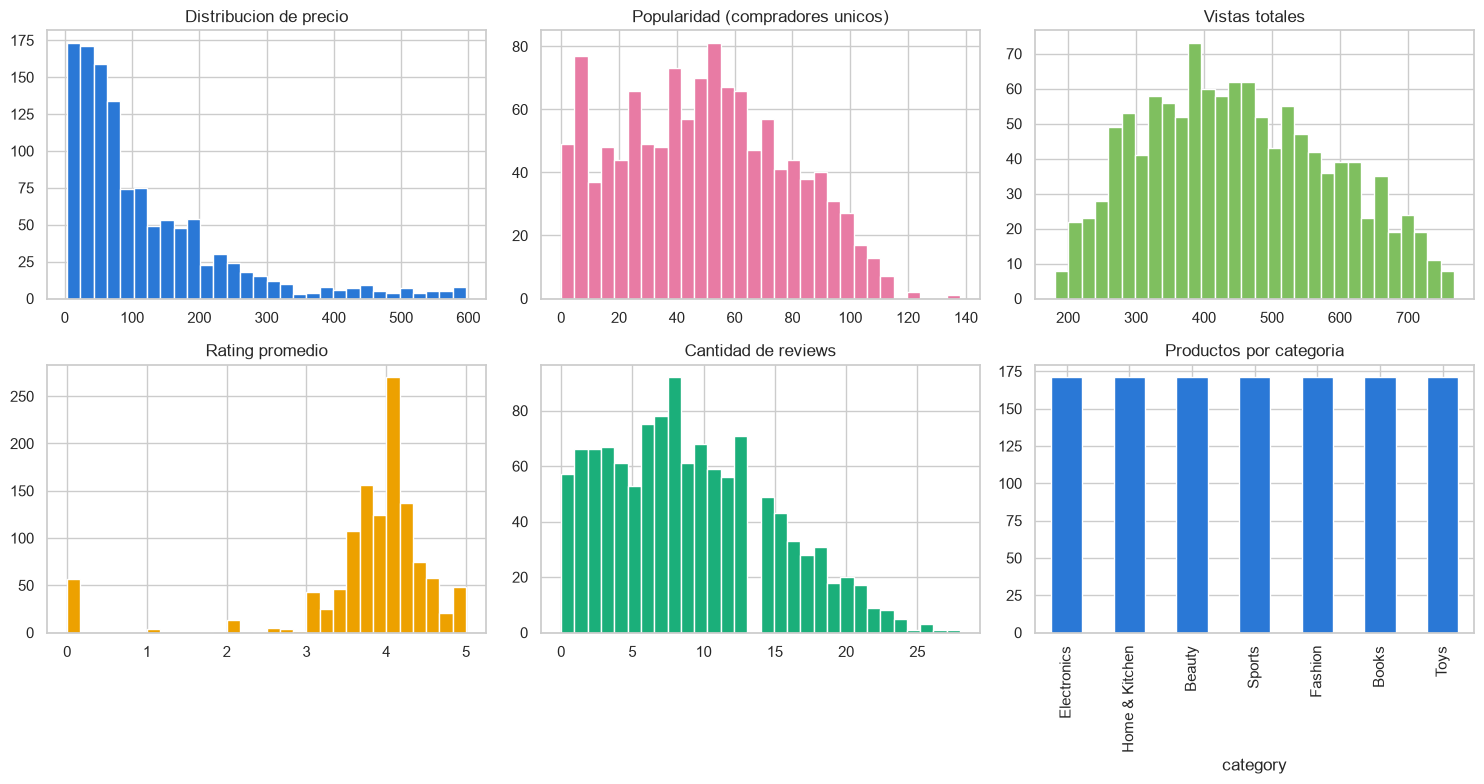

In [9]:
# Visualizacion: distribuciones de features de producto
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features_producto['price_usd'].hist(ax=axes[0,0], bins=30, color='#2a78d6', edgecolor='white')
axes[0,0].set_title('Distribucion de precio')

features_producto['popularidad'].hist(ax=axes[0,1], bins=30, color='#e87ba4', edgecolor='white')
axes[0,1].set_title('Popularidad (compradores unicos)')

features_producto['n_views'].hist(ax=axes[0,2], bins=30, color='#7fbf5f', edgecolor='white')
axes[0,2].set_title('Vistas totales')

features_producto['rating_promedio'].hist(ax=axes[1,0], bins=30, color='#eda100', edgecolor='white')
axes[1,0].set_title('Rating promedio')

features_producto['n_ratings'].hist(ax=axes[1,1], bins=30, color='#1baf7a', edgecolor='white')
axes[1,1].set_title('Cantidad de reviews')

features_producto['category'].value_counts().plot(kind='bar', ax=axes[1,2], color='#2a78d6')
axes[1,2].set_title('Productos por categoria')

plt.tight_layout()
plt.show()

---
## 4. Features de usuario (para cold start)

### Que es?

Un DataFrame con una fila por usuario y todas sus caracteristicas derivadas.

### Que features se crearon?

| Feature | Origen | Descripcion |
|---------|--------|-------------|
| `age` | customers | Edad del usuario |
| `country` | customers | Pais de registro |
| `marketing_opt_in` | customers | Si acepto marketing |
| `n_sessions` | sessions | Cantidad de sesiones |
| `n_purchases` | orders | Compras realizadas |
| `ticket_promedio` | orders | Gasto promedio por compra |
| `n_products_viewed` | events | Productos distintos vistos |
| `n_products_carted` | events | Productos distintos en carrito |
| `rating_promedio_usr` | reviews | Rating promedio que otorga |

### Para que sirve?

- **Cold start de clientes nuevos**: cuando un cliente se registra pero no tiene historial de compras, se usa su perfil demografico (edad, pais) para recomendarle lo que suelen comprar usuarios similares.

In [10]:
# Features demograficas
df_usr = customers[['customer_id', 'age', 'country', 'marketing_opt_in']].copy()
df_usr = df_usr.set_index('customer_id')

# Sesiones por usuario
n_sessions = sessions.groupby('customer_id').size().rename('n_sessions')
df_usr = df_usr.join(n_sessions, how='left')

# Compras (desde orders)
n_purchases = orders.groupby('customer_id').size().rename('n_purchases')
ticket_prom = orders.groupby('customer_id')['total_usd'].mean().rename('ticket_promedio')
df_usr = df_usr.join(n_purchases, how='left').join(ticket_prom, how='left')

# Productos vistos y en carrito (desde events)
pv_user = events_con_user[events_con_user['event_type'] == 'page_view']
ac_user = events_con_user[events_con_user['event_type'] == 'add_to_cart']

n_viewed = pv_user.groupby('customer_id')['product_id'].nunique().rename('n_products_viewed')
n_carted = ac_user.groupby('customer_id')['product_id'].nunique().rename('n_products_carted')
df_usr = df_usr.join(n_viewed, how='left').join(n_carted, how='left')

# Rating promedio dado por el usuario
rev_con_customer = reviews.merge(
    oi_con_order[['order_id', 'customer_id']].drop_duplicates('order_id'),
    on='order_id', how='left'
)
rating_usr = rev_con_customer.groupby('customer_id')['rating'].mean().rename('rating_promedio_usr')
df_usr = df_usr.join(rating_usr, how='left')

df_usr = df_usr.fillna(0)
features_usuario = df_usr.reset_index()

print(f'=== FEATURES DE USUARIO ===')
print(f'  Usuarios: {len(features_usuario):,}')
print(f'  Columnas: {list(features_usuario.columns)}')
print(f'\nPrimeras filas:')
features_usuario.head(10)

=== FEATURES DE USUARIO ===
  Usuarios: 20,000
  Columnas: ['customer_id', 'age', 'country', 'marketing_opt_in', 'n_sessions', 'n_purchases', 'ticket_promedio', 'n_products_viewed', 'n_products_carted', 'rating_promedio_usr']

Primeras filas:


,customer_id,age,country,marketing_opt_in,n_sessions,n_purchases,ticket_promedio,n_products_viewed,n_products_carted,rating_promedio_usr
0,1,71,JP,True,5.0,2.0,57.695,28.0,8.0,3.000000
1,2,26,IN,False,3.0,2.0,34.260,17.0,2.0,0.000000
2,3,21,BR,True,5.0,1.0,66.720,30.0,4.0,0.000000
3,4,63,FR,True,9.0,2.0,139.930,29.0,6.0,0.000000
4,5,19,BR,True,9.0,3.0,90.430,34.0,9.0,3.250000
5,6,28,US,False,7.0,4.0,96.850,33.0,8.0,4.000000
6,7,48,IN,False,7.0,2.0,48.405,25.0,9.0,0.000000
7,8,33,GB,True,5.0,1.0,207.400,24.0,2.0,0.000000
8,9,32,US,True,4.0,1.0,122.510,16.0,3.0,0.000000
9,10,39,JP,True,6.0,3.0,132.950,36.0,11.0,3.666667


In [11]:
# Estadisticas de las features de usuario
print('=== ESTADISTICAS DE FEATURES DE USUARIO ===')
features_usuario.describe().round(2)

=== ESTADISTICAS DE FEATURES DE USUARIO ===


,customer_id,age,n_sessions,n_purchases,ticket_promedio,n_products_viewed,n_products_carted,rating_promedio_usr
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,10000.50,46.49,6.00,1.68,109.14,26.48,7.11,1.03
std,5773.65,16.77,2.47,1.29,122.42,12.01,3.98,1.79
min,1.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,5000.75,32.00,4.00,1.00,27.14,18.00,4.00,0.00
50%,10000.50,46.50,6.00,2.00,82.58,25.00,7.00,0.00
75%,15000.25,61.00,8.00,2.00,151.05,34.00,10.00,2.00
max,20000.00,75.00,17.00,9.00,2680.64,85.00,28.00,5.00


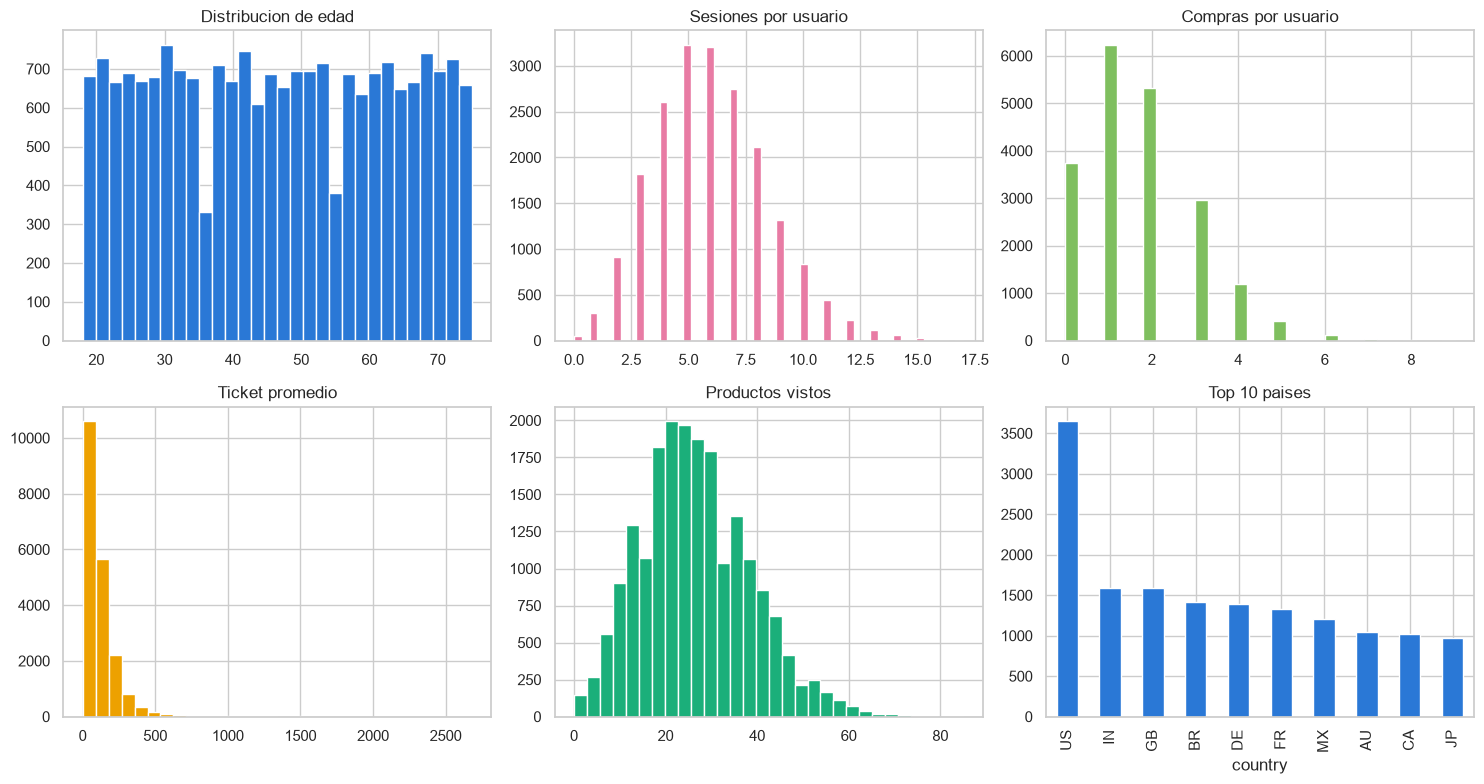

In [12]:
# Visualizacion: distribuciones de features de usuario
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features_usuario['age'].hist(ax=axes[0,0], bins=30, color='#2a78d6', edgecolor='white')
axes[0,0].set_title('Distribucion de edad')

features_usuario['n_sessions'].hist(ax=axes[0,1], bins=50, color='#e87ba4', edgecolor='white')
axes[0,1].set_title('Sesiones por usuario')

features_usuario['n_purchases'].hist(ax=axes[0,2], bins=30, color='#7fbf5f', edgecolor='white')
axes[0,2].set_title('Compras por usuario')

features_usuario['ticket_promedio'].hist(ax=axes[1,0], bins=30, color='#eda100', edgecolor='white')
axes[1,0].set_title('Ticket promedio')

features_usuario['n_products_viewed'].hist(ax=axes[1,1], bins=30, color='#1baf7a', edgecolor='white')
axes[1,1].set_title('Productos vistos')

features_usuario['country'].value_counts().head(10).plot(kind='bar', ax=axes[1,2], color='#2a78d6')
axes[1,2].set_title('Top 10 paises')

plt.tight_layout()
plt.show()

---
## 5. Preprocesamiento para modelado

Se aplican tres transformaciones:

| Transformacion | Que hace | Por que |
|----------------|----------|--------|
| **Matriz pivote** | Convierte la lista de scores en tabla usuario x producto | SVD/ALS necesitan esta estructura |
| **LabelEncoder** | Convierte texto a numeros (category, country) | Los modelos no entienden texto |
| **StandardScaler** | Centra los numeros en torno a 0 | Que un numero grande no domine sobre uno chico |

In [13]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 5a. Matriz pivote usuario x producto
interaction_matrix = matriz_usuario_item.pivot_table(
    index='customer_id',
    columns='product_id',
    values='score',
    fill_value=0
)

print(f'=== MATRIZ INTERACTION ===')
print(f'  Forma: {interaction_matrix.shape[0]} usuarios x {interaction_matrix.shape[1]} productos')
print(f'\nPrimeras filas (primeras 10 columnas):')
interaction_matrix.iloc[:8, :10]

=== MATRIZ INTERACTION ===
  Forma: 19945 usuarios x 1197 productos

Primeras filas (primeras 10 columnas):


product_id,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
customer_id,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# 5b. Preprocesar features de producto
product_features = features_producto.copy()

# Encoding de category
le_cat = LabelEncoder()
product_features['category_encoded'] = le_cat.fit_transform(product_features['category'])

# Escalado de features numericas
scaler_prod = StandardScaler()
num_cols_prod = ['price_usd', 'cost_usd', 'margin_usd', 'popularidad',
                 'rating_promedio', 'n_views', 'n_cart', 'n_purchases']
product_features[num_cols_prod] = scaler_prod.fit_transform(product_features[num_cols_prod])

print(f'=== PRODUCT FEATURES (preprocesado) ===')
print(f'  Forma: {product_features.shape}')
print(f'\nPrimeras filas:')
product_features.head(10)

=== PRODUCT FEATURES (preprocesado) ===
  Forma: (1197, 12)

Primeras filas:


,product_id,category,price_usd,cost_usd,margin_usd,n_views,n_cart,n_purchases,popularidad,rating_promedio,n_ratings,category_encoded
0,1.0,Electronics,3.764426,3.473210,3.943738,-1.934828,-1.674890,0.0,-1.652435,1.288984,1.0,2
1,2.0,Electronics,3.161325,2.342342,4.335454,-1.839400,-1.674890,0.0,-1.652435,-3.822213,0.0,2
2,3.0,Electronics,3.582618,2.929115,4.423876,-1.736632,-1.587177,0.0,-1.582511,1.288984,1.0,2
3,4.0,Electronics,1.240681,0.958808,1.631017,-0.686926,-1.280181,0.0,-1.232893,0.777864,2.0,2
4,5.0,Electronics,-0.470153,-0.441646,-0.478534,0.847260,0.196322,0.0,-0.184039,0.850881,14.0,2
5,6.0,Electronics,1.997922,1.825395,2.125105,-1.465030,-1.514083,0.0,-1.477626,-0.244375,2.0,2
6,7.0,Electronics,1.900539,1.387745,2.642818,-1.259493,-1.543321,0.0,-1.337779,0.948237,3.0,2
7,8.0,Electronics,1.824389,1.886383,1.549343,-1.222790,-1.543321,0.0,-1.582511,0.266744,1.0,2
8,9.0,Electronics,-0.260760,-0.227872,-0.295839,0.553636,0.386368,0.0,0.864816,-0.171358,14.0,2
9,10.0,Electronics,-0.287509,-0.209437,-0.400686,0.568317,0.430224,0.0,0.305427,0.120710,21.0,2


In [15]:
# 5c. Preprocesar features de usuario
user_features = features_usuario.copy()

# Encoding de country
le_country = LabelEncoder()
user_features['country_encoded'] = le_country.fit_transform(user_features['country'])

# Escalado de features numericas
scaler_usr = StandardScaler()
num_cols_usr = ['age', 'n_sessions', 'n_purchases', 'ticket_promedio',
                'n_products_viewed', 'n_products_carted', 'rating_promedio_usr']
user_features[num_cols_usr] = scaler_usr.fit_transform(user_features[num_cols_usr])

print(f'=== USER FEATURES (preprocesado) ===')
print(f'  Forma: {user_features.shape}')
print(f'\nPrimeras filas:')
user_features.head(10)

=== USER FEATURES (preprocesado) ===
  Forma: (20000, 11)

Primeras filas:


,customer_id,age,country,marketing_opt_in,n_sessions,n_purchases,ticket_promedio,n_products_viewed,n_products_carted,rating_promedio_usr,country_encoded
0,1,1.461601,JP,True,-0.405161,0.248274,-0.420208,0.126638,0.222683,1.099625,9
1,2,-1.222156,IN,False,-1.215482,0.248274,-0.611638,-0.789613,-1.284054,-0.577636,8
2,3,-1.520351,BR,True,-0.405161,-0.525165,-0.346487,0.293230,-0.781809,-0.577636,2
3,4,0.984488,FR,True,1.215482,0.248274,0.251533,0.209934,-0.279563,-0.577636,6
4,5,-1.639629,BR,True,1.215482,1.021713,-0.152811,0.626412,0.473806,1.239396,2
5,6,-1.102878,US,False,0.405161,1.795152,-0.100369,0.543116,0.222683,1.658711,15
6,7,0.089903,IN,False,0.405161,0.248274,-0.496094,-0.123248,0.473806,-0.577636,8
7,8,-0.804683,GB,True,-0.405161,-0.525165,0.802665,-0.206544,-1.284054,-0.577636,7
8,9,-0.864322,US,True,-0.810321,-0.525165,0.109236,-0.872909,-1.032931,-0.577636,15
9,10,-0.446848,JP,True,0.000000,1.021713,0.194516,0.793003,0.976052,1.472349,9


In [16]:
# Resumen de estructuras generadas
print('=' * 60)
print('RESUMEN DE ESTRUCTURAS GENERADAS')
print('=' * 60)

print(f'\n1. interaction_matrix:')
print(f'   Forma: {interaction_matrix.shape}')
print(f'   Para: Collaborative Filtering (SVD/ALS)')

print(f'\n2. product_features:')
print(f'   Forma: {product_features.shape}')
print(f'   Para: Content-Based y Cold Start')

print(f'\n3. user_features:')
print(f'   Forma: {user_features.shape}')
print(f'   Para: Cold Start de clientes nuevos')

print(f'\n4. matriz_usuario_item (cruda):')
print(f'   Forma: {matriz_usuario_item.shape}')
print(f'   Para: Analisis y modelos alternativos')

RESUMEN DE ESTRUCTURAS GENERADAS

1. interaction_matrix:
   Forma: (19945, 1197)
   Para: Collaborative Filtering (SVD/ALS)

2. product_features:
   Forma: (1197, 12)
   Para: Content-Based y Cold Start

3. user_features:
   Forma: (20000, 11)
   Para: Cold Start de clientes nuevos

4. matriz_usuario_item (cruda):
   Forma: (529593, 3)
   Para: Analisis y modelos alternativos


## 6. Guardar archivos procesados

In [17]:
import os

os.makedirs('../Data/Processed', exist_ok=True)

interaction_matrix.to_csv('../Data/Processed/interaction_matrix.csv')
product_features.to_csv('../Data/Processed/product_features.csv', index=False)
user_features.to_csv('../Data/Processed/user_features.csv', index=False)
matriz_usuario_item.to_csv('../Data/Processed/user_item_df.csv', index=False)

print('Archivos guardados en Data/Processed/:')
print('  - interaction_matrix.csv')
print('  - product_features.csv')
print('  - user_features.csv')
print('  - user_item_df.csv')

Archivos guardados en Data/Processed/:
  - interaction_matrix.csv
  - product_features.csv
  - user_features.csv
  - user_item_df.csv


---
## 7. Resumen, conclusiones y recomendaciones para el modelado

### Resumen de lo realizado

Se proceso el dataset completo del e-commerce (7 tablas, ~1M de registros) para generar las estructuras necesarias para un sistema de recomendacion:

| Estructura | Tamaño | Destino |
|------------|--------|---------|
| `interaction_matrix` | 19,945 usuarios x 1,197 productos | Collaborative Filtering |
| `product_features` | 1,197 productos x 12 columnas | Content-Based |
| `user_features` | 20,000 usuarios x 11 columnas | Cold Start |
| `matriz_usuario_item` | 529,593 interacciones | Analisis |

### Conclusiones

1. **Esparsidad alta (97.78%)**: la mayoria de los usuarios solo interactuo con pocos productos. Esto confirma que se necesita collaborative filtering (SVD/ALS) para predecir las interacciones faltantes.

2. **Distribucion de scores**: la mayoria de los usuarios tienen scores bajos (page_view), lo que indica que la mayoria de las interacciones son pasivas (solo vistas). Las interacciones activas (add_to_cart, purchase) son la minoria.

3. **Cold start**: 55 clientes (0.27%) no tienen ninguna sesion. Estos requieren recomendaciones basadas en su perfil demografico (edad, pais) y en la popularidad de los productos.

4. **Dataset sintético**: las conversiones son uniformes (~28% en todos los dispositivos, fuentes y paises), lo que limita el poder predictivo de las features demograficas. En un dataset real, estas features serian mucho mas utiles.

### Recomendaciones para el modelado

1. **Collaborative Filtering (SVD/ALS)**: usar `interaction_matrix` como entrada. Es el modelo principal para clientes con historial.

2. **Content-Based**: usar `product_features` para calcular similitud entre productos (cosine similarity). Util para complementar el collaborative filtering.

3. **Hibrido**: combinar collaborative filtering + content-based para cubrir:
   - Clientes nuevos (cold start) -> content-based con features de usuario
   - Productos nuevos -> content-based con features de producto
   - Clientes viejos -> collaborative filtering

4. **Evaluacion**: usar Precision@K y Recall@K para medir la calidad de las recomendaciones. RMSE solo para predecir ratings.

5. **Split temporal**: como las fechas fueron corregidas artificialmente, se recomienda un split aleatorio por usuario (no temporal) para train/test.